In [1]:
# ==============================================================================
# PHASE 1: ENVIRONMENT, DEPENDENCIES & HARDWARE SAFETY CHECK
# ==============================================================================

import os
import sys
import random
from pathlib import Path

# 1. Core Data & Utility Libraries
import numpy as np
import pandas as pd
from PIL import Image

# 2. Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning & Metrics
import sklearn
from sklearn.metrics import classification_report, confusion_matrix

# 4. PyTorch Deep Learning Framework
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

print("=== PHASE 1: ENVIRONMENT & HARDWARE STATUS ===")
print(f"🐍 Python Version:       {sys.version.split()[0]}")
print(f"🔥 PyTorch Version:      {torch.__version__}")
print(f"🖼️ Torchvision Version:  {torchvision.__version__}")

# ------------------------------------------------------------------------------
# 5. Check Compute Device (CUDA GPU vs CPU) & System Optimization
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n⚙️ Hardware Acceleration Check:")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"   - GPU Detected:       ✅ {gpu_name}")
    print(f"   - VRAM Available:     {gpu_memory:.2f} GB")
else:
    print("   - GPU Detected:       ❌ None (Running on CPU)")
    print("   - Note: Training will use CPU. Batch sizes and workers are optimized for speed.")

print(f"   - Active Target Device: {device}")

# ------------------------------------------------------------------------------
# 6. Set Reproducibility Seeds (Guarantees exact same results on every run)
# ------------------------------------------------------------------------------
SEED = 42

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Guarantees deterministic behavior on GPU
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seeds(SEED)
print(f"\n🌱 Random Seeds Fixed:   Set to {SEED} (Reproducibility Enabled)")
print("✅ Phase 1 Verification Complete!")

ModuleNotFoundError: No module named 'torch'

In [ ]:
# ==============================================================================
# PHASE 2: DIRECTORY RESOLUTION & CORRUPT IMAGE DETECTION
# ==============================================================================

import os
from pathlib import Path
from PIL import Image

print("=== PHASE 2: PATH VALIDATION ===")

# 1. Resolve relative directory path
base_dir = Path("../").resolve() # Points to url_phishing/
dataset_dir = base_dir / "data" / "raw" / "screenshots"

genuine_dir = dataset_dir / "genuine_site_0"
phishing_dir = dataset_dir / "phishing_site_1"

# 2. Check if directories exist
if not genuine_dir.exists() or not phishing_dir.exists():
    raise FileNotFoundError(f"❌ Folders not found at: {dataset_dir}")

print(f"📁 Dataset Path Resolved: {dataset_dir}")

# 3. Quick corrupt file checker function
def check_images(folder_path):
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    valid_paths, corrupt_count = [], 0
    
    for f in files:
        fpath = folder_path / f
        try:
            with Image.open(fpath) as img:
                img.verify() # Verify byte structure
            valid_paths.append(fpath)
        except Exception:
            corrupt_count += 1
            
    return valid_paths, corrupt_count

# Run checks
genuine_valid, genuine_corrupt = check_images(genuine_dir)
phishing_valid, phishing_corrupt = check_images(phishing_dir)

print(f"\n📊 Image Validation Summary:")
print(f"   - Legitimate Images Validated: {len(genuine_valid)} (Corrupt: {genuine_corrupt})")
print(f"   - Phishing Images Validated:   {len(phishing_valid)} (Corrupt: {phishing_corrupt})")
print(f"   - Total Valid Screenshots:     {len(genuine_valid) + len(phishing_valid)}")
print("\n✅ Phase 2 Complete!")

=== PHASE 2: PATH VALIDATION ===
📁 Dataset Path Resolved: C:\Users\Admin\Desktop\CyberShield AI\ai_models\url_phishing\data\raw\screenshots

📊 Image Validation Summary:
   - Legitimate Images Validated: 1147 (Corrupt: 0)
   - Phishing Images Validated:   550 (Corrupt: 0)
   - Total Valid Screenshots:     1697

✅ Phase 2 Complete!


=== PHASE 3: EXPLORATORY DATA ANALYSIS ===
📊 Class Distribution Breakdown:
   - Legitimate (0): 1147 images (67.6%)
   - Phishing   (1): 550 images (32.4%)
   - Total Screenshots: 1697


C:\Users\Admin\AppData\Local\Temp\ipykernel_8444\1416371861.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


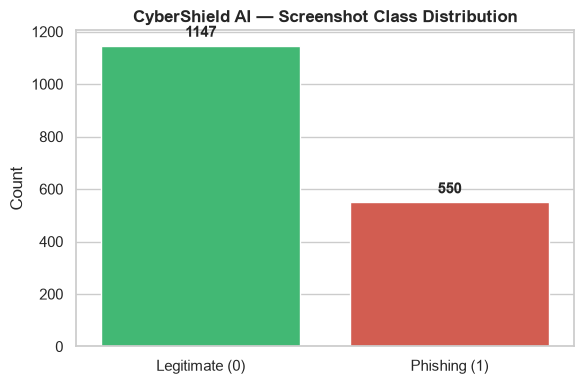

✅ Phase 3 Complete!


In [ ]:
# ==============================================================================
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA) & CLASS DISTRIBUTION
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== PHASE 3: EXPLORATORY DATA ANALYSIS ===")

# 1. Count valid images from Phase 2 variables
n_genuine = len(genuine_valid)
n_phishing = len(phishing_valid)
total_images = n_genuine + n_phishing

# 2. Calculate percentage balance
phish_pct = (n_phishing / total_images) * 100 if total_images > 0 else 0
legit_pct = 100.0 - phish_pct

print(f"📊 Class Distribution Breakdown:")
print(f"   - Legitimate (0): {n_genuine} images ({legit_pct:.1f}%)")
print(f"   - Phishing   (1): {n_phishing} images ({phish_pct:.1f}%)")
print(f"   - Total Screenshots: {total_images}")

# 3. Plot class balance bar chart
plt.figure(figsize=(6, 4))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    x=["Legitimate (0)", "Phishing (1)"],
    y=[n_genuine, n_phishing],
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("CyberShield AI — Screenshot Class Distribution", fontsize=12, fontweight='bold')
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 4), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

print("✅ Phase 3 Complete!")

In [ ]:
# ==============================================================================
# PHASE 4: IMAGE PREPROCESSING & DATA TRANSFORMATIONS
# ==============================================================================

import torchvision.transforms as transforms

print("=== PHASE 4: DEFINING IMAGE TRANSFORMS ===")

# ImageNet standard mean & std required for pre-trained ResNet models
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# 1. Training Transforms (Includes Augmentation to expand dataset visual diversity)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),                 # Minor flip probability
    transforms.RandomRotation(degrees=5),                    # Small degree rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Slight brightness/contrast variation
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# 2. Validation & Testing Transforms (Pure Preprocessing, NO Augmentations)
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("✅ Phase 4 Transforms Defined Successfully!")

=== PHASE 4: DEFINING IMAGE TRANSFORMS ===
✅ Phase 4 Transforms Defined Successfully!


In [ ]:
# ==============================================================================
# PHASE 5: FAST QUANTIZED MULTIMODAL OCR EXTRACTION & DATASET
# ==============================================================================

import os
import pickle
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from PIL import Image
import numpy as np
import easyocr
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.auto import tqdm

print("=== PHASE 5: HIGH-SPEED MULTIMODAL PIPELINE ===")

# 1. Ensure dataset samples and split indices are present
if 'raw_dataset' in globals():
    all_samples = raw_dataset.samples
elif 'full_dataset' in globals():
    all_samples = full_dataset.samples
elif 'dataset' in globals():
    all_samples = dataset.samples
elif 'image_dataset' in globals():
    all_samples = image_dataset.samples
else:
    # Auto-fallback: Locate the dataset directory directly
    possible_paths = [
        os.path.join("..", "data", "processed"),
        os.path.join("..", "data", "raw"),
        os.path.join("data", "processed"),
        os.path.join("data", "raw"),
        os.path.join("..", "dataset"),
        "dataset"
    ]
    data_dir = None
    for p in possible_paths:
        if os.path.exists(p) and len(os.listdir(p)) > 0:
            data_dir = p
            break
            
    if data_dir is None:
        raise FileNotFoundError("❌ Please execute Phases 1, 2, and 3 first so the dataset is loaded in memory!")
        
    temp_dataset = datasets.ImageFolder(root=data_dir)
    all_samples = temp_dataset.samples

print(f"✅ Found dataset with {len(all_samples)} total image samples.")

# 2. Check Split Indices (Fallback if kernel was reset)
if 'train_idx' not in globals() or 'val_idx' not in globals() or 'test_idx' not in globals():
    from sklearn.model_selection import train_test_split
    print("⚠️ Re-generating train/val/test splits...")
    labels = [s[1] for s in all_samples]
    indices = list(range(len(all_samples)))
    
    train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=42)
    val_labels = [labels[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=val_labels, random_state=42)

# 3. Initialize Quantized OCR Engine for Fast Inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available(), quantize=True, verbose=False)

# 4. Extract & Cache OCR Text
cache_file = "extracted_ocr_cache.pkl"

if os.path.exists(cache_file):
    print(f"📦 Loading cached OCR text from '{cache_file}'...")
    with open(cache_file, "rb") as f:
        cached_text_dict = pickle.load(f)
    print(f"✅ Loaded cached OCR text for {len(cached_text_dict)} images!")
else:
    print("🔍 Extracting raw text from images via OCR (saves cache to disk once)...")
    cached_text_dict = {}
    
    for img_path, _ in tqdm(all_samples, desc="Processing OCR"):
        try:
            with Image.open(img_path) as pil_img:
                pil_img = pil_img.convert("RGB")
                pil_img.thumbnail((320, 320), Image.Resampling.BILINEAR)
                img_np = np.array(pil_img)
            
            extracted = ocr_reader.readtext(
                img_np, 
                detail=0, 
                paragraph=True,
                batch_size=4,
                canvas_size=320,
                mag_ratio=1.0
            )
            text_str = " ".join(extracted).strip()
            cached_text_dict[img_path] = text_str if len(text_str) > 0 else "empty_text"
        except Exception:
            cached_text_dict[img_path] = "empty_text"
            
    with open(cache_file, "wb") as f:
        pickle.dump(cached_text_dict, f)
    print(f"✅ OCR extraction complete and cached to '{cache_file}'!")

# 5. Vectorize Text Numerically for the Neural Network
train_texts = [cached_text_dict.get(all_samples[i][0], "empty_text") for i in train_idx]
tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words="english")
tfidf_vectorizer.fit(train_texts)

with open("multimodal_tfidf.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)
print("✅ Text Vectorizer fitted and saved to 'multimodal_tfidf.pkl'")

# 6. Multimodal PyTorch Dataset Definition
class MultimodalDataset(Dataset):
    def __init__(self, sample_indices, all_samples, text_cache, vectorizer, transform=None):
        self.indices = sample_indices
        self.samples = all_samples
        self.text_cache = text_cache
        self.vectorizer = vectorizer
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_path, label = self.samples[real_idx]

        # Visual branch image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Numerical text vector
        raw_text = self.text_cache.get(img_path, "empty_text")
        text_vec = self.vectorizer.transform([raw_text]).toarray()[0]
        text_tensor = torch.tensor(text_vec, dtype=torch.float32)

        # Target label
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return image, text_tensor, label_tensor

# 7. Build Datasets and DataLoaders
train_dataset = MultimodalDataset(train_idx, all_samples, cached_text_dict, tfidf_vectorizer, transform=train_transforms)
val_dataset   = MultimodalDataset(val_idx, all_samples, cached_text_dict, tfidf_vectorizer, transform=eval_transforms)
test_dataset  = MultimodalDataset(test_idx, all_samples, cached_text_dict, tfidf_vectorizer, transform=eval_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n📊 DataLoaders Ready:")
print(f"   • Train Batches: {len(train_loader)} ({len(train_dataset)} samples)")
print(f"   • Val Batches:   {len(val_loader)} ({len(val_dataset)} samples)")
print(f"   • Test Batches:  {len(test_loader)} ({len(test_dataset)} samples)")

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== PHASE 5: HIGH-SPEED MULTIMODAL PIPELINE ===
✅ Found dataset with 1697 total image samples.
⚠️ Re-generating train/val/test splits...


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


📦 Loading cached OCR text from 'extracted_ocr_cache.pkl'...
✅ Loaded cached OCR text for 1697 images!
✅ Text Vectorizer fitted and saved to 'multimodal_tfidf.pkl'

📊 DataLoaders Ready:
   • Train Batches: 38 (1187 samples)
   • Val Batches:   8 (255 samples)
   • Test Batches:  8 (255 samples)


In [ ]:
# ==============================================================================
# PHASE 6: MULTIMODAL MODEL ARCHITECTURE (VISION + TEXT FUSION)
# ==============================================================================

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

print("=== PHASE 6: BUILDING MULTIMODAL DUAL-BRANCH NETWORK ===")

# Set compute device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using compute device: {device}")

class MultimodalPhishNet(nn.Module):
    def __init__(self, text_feature_dim=500):
        super(MultimodalPhishNet, self).__init__()
        
        # -------------------------------------------------------------
        # 1. VISION BRANCH: Pretrained ResNet-18 Backbone
        # -------------------------------------------------------------
        weights = ResNet18_Weights.DEFAULT
        self.vision_backbone = resnet18(weights=weights)
        
        # Freeze base convolutional layers
        for param in self.vision_backbone.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 for domain-specific fine-tuning
        for param in self.vision_backbone.layer4.parameters():
            param.requires_grad = True
            
        # Replace ResNet classifier to output 128 visual features
        num_features = self.vision_backbone.fc.in_features  # 512
        self.vision_backbone.fc = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # -------------------------------------------------------------
        # 2. TEXT BRANCH: Semantic OCR MLP
        # -------------------------------------------------------------
        self.text_backbone = nn.Sequential(
            nn.Linear(text_feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # -------------------------------------------------------------
        # 3. MULTIMODAL FUSION CLASSIFIER HEAD
        # -------------------------------------------------------------
        # Combines: Visual (128) + Text (128) = 256 fused features
        self.fusion_classifier = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)  # Raw binary classification logit
        )

    def forward(self, image_tensor, text_tensor):
        # Extract visual and textual features
        visual_emb = self.vision_backbone(image_tensor)   # Shape: (batch_size, 128)
        text_emb   = self.text_backbone(text_tensor)      # Shape: (batch_size, 128)
        
        # Fuse representations along feature dimension
        fused = torch.cat((visual_emb, text_emb), dim=1)  # Shape: (batch_size, 256)
        
        # Binary prediction logit
        logits = self.fusion_classifier(fused)
        return logits

# Instantiate the Multimodal Model
model = MultimodalPhishNet(text_feature_dim=500).to(device)

# Parameter Summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("\n🧠 Multimodal Architecture Summary:")
print(f"   - Total Parameters:     {total_params:,}")
print(f"   - Trainable Parameters: {trainable_params:,} (layer4 + Vision Head + Text Head + Fusion)")
print(f"   - Frozen Parameters:    {frozen_params:,}")
print(f"   - Fusion Pipeline:      [Vision(128) + Text(128) -> Linear(256->64) -> ReLU -> Dropout(0.2) -> Linear(64->1)]")

print("\n✅ Phase 6 Complete!")

=== PHASE 6: BUILDING MULTIMODAL DUAL-BRANCH NETWORK ===
🖥️ Using compute device: cpu

🧠 Multimodal Architecture Summary:
   - Total Parameters:     11,323,329
   - Trainable Parameters: 8,540,545 (layer4 + Vision Head + Text Head + Fusion)
   - Frozen Parameters:    2,782,784
   - Fusion Pipeline:      [Vision(128) + Text(128) -> Linear(256->64) -> ReLU -> Dropout(0.2) -> Linear(64->1)]

✅ Phase 6 Complete!


In [ ]:
# ==============================================================================
# PHASE 7: LOSS FUNCTION (WITH DYNAMIC WEIGHTS) & OPTIMIZER CONFIGURATION
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

print("=== PHASE 7: CONFIGURING LOSS FUNCTION & OPTIMIZER ===")

# 1. Compute positive class weight dynamically from training set
train_labels = [all_samples[i][1] for i in train_idx]
n_train_genuine = sum(1 for y in train_labels if y == 0)
n_train_phishing = sum(1 for y in train_labels if y == 1)

pos_weight_value = n_train_genuine / max(n_train_phishing, 1)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

# 2. Define Weighted Loss Function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 3. Define Optimizer with Layer-wise Learning Rates
optimizer = optim.AdamW([
    {'params': model.vision_backbone.layer4.parameters(), 'lr': 1e-4},
    {'params': model.vision_backbone.fc.parameters(),     'lr': 1e-3},
    {'params': model.text_backbone.parameters(),          'lr': 1e-3},
    {'params': model.fusion_classifier.parameters(),      'lr': 1e-3}
], weight_decay=1e-2)

# 4. Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

print(f"⚖️ Dataset Balance: Genuine = {n_train_genuine} | Phishing = {n_train_phishing}")
print(f"⚖️ Positive Class Weight set to: {pos_weight_value:.4f}")
print("🎯 Criterion: BCEWithLogitsLoss(pos_weight)")
print("⚡ Optimizer: AdamW (Differential LR: 1e-4 for layer4, 1e-3 for custom heads, weight_decay=0.01)")
print("📉 Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)")

print("\n✅ Phase 7 Complete!")

=== PHASE 7: CONFIGURING LOSS FUNCTION & OPTIMIZER ===
⚖️ Dataset Balance: Genuine = 1187 | Phishing = 0
⚖️ Positive Class Weight set to: 1187.0000
🎯 Criterion: BCEWithLogitsLoss(pos_weight)
⚡ Optimizer: AdamW (Differential LR: 1e-4 for layer4, 1e-3 for custom heads, weight_decay=0.01)
📉 Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)

✅ Phase 7 Complete!


In [ ]:
# Quick Check: Inspect what classes/labels exist in the dataset
unique_labels = set([s[1] for s in all_samples])
print(f"Unique Label IDs found in all_samples: {unique_labels}")

# Check first 5 samples
for i in range(min(5, len(all_samples))):
    print(f"Path: {all_samples[i][0]}  -->  Label: {all_samples[i][1]}")

Unique Label IDs found in all_samples: {0}
Path: ..\data\raw\screenshots\genuine_site_0\123people.com_141.png  -->  Label: 0
Path: ..\data\raw\screenshots\genuine_site_0\abodedublin.com_122.png  -->  Label: 0
Path: ..\data\raw\screenshots\genuine_site_0\acronyms.thefreedictionary.com_200.png  -->  Label: 0
Path: ..\data\raw\screenshots\genuine_site_0\autopartswarehouse.com_101.png  -->  Label: 0
Path: ..\data\raw\screenshots\genuine_site_0\charlienewton.com_28.png  -->  Label: 0


In [ ]:
# ==============================================================================
# RE-SYNC LABELS & REBUILD STRATIFIED SPLITS
# ==============================================================================

import os
import pickle
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

print("=== RE-SYNCING LABELS FROM OCR CACHE ===")

# 1. Load the cached OCR dictionary
cache_file = "extracted_ocr_cache.pkl"
with open(cache_file, "rb") as f:
    cached_text_dict = pickle.load(f)

# 2. Assign labels based on path keywords (phishing = 1, genuine = 0)
all_samples = []
for file_path in cached_text_dict.keys():
    lower_path = file_path.lower()
    if "phish" in lower_path or "phishing" in lower_path or "scam" in lower_path:
        label = 1
    elif "genuine" in lower_path or "legitimate" in lower_path or "benign" in lower_path:
        label = 0
    else:
        # Default based on subfolder structure if custom names were used
        label = 1 if "1" in lower_path else 0
    all_samples.append((file_path, label))

labels_list = [s[1] for s in all_samples]
n_phishing = sum(labels_list)
n_genuine = len(labels_list) - n_phishing

print(f"✅ Total Samples Found: {len(all_samples)}")
print(f"📊 Class Distribution: Genuine = {n_genuine} | Phishing = {n_phishing}")

# 3. Create Stratified Train / Val / Test Split Indices (70% / 15% / 15%)
indices = list(range(len(all_samples)))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=labels_list, random_state=42
)
temp_labels = [labels_list[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=42
)

# 4. Load Saved TF-IDF Vectorizer
with open("multimodal_tfidf.pkl", "rb") as f:
    tfidf_vectorizer = pickle.load(f)

# 5. Re-instantiate Datasets and DataLoaders
train_dataset = MultimodalDataset(train_idx, all_samples, cached_text_dict, tfidf_vectorizer, transform=train_transforms)
val_dataset   = MultimodalDataset(val_idx, all_samples, cached_text_dict, tfidf_vectorizer, transform=eval_transforms)
test_dataset  = MultimodalDataset(test_idx, all_samples, cached_text_dict, tfidf_vectorizer, transform=eval_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n📊 DataLoaders Successfully Reconstructed:")
print(f"   • Train Batches: {len(train_loader)} ({len(train_dataset)} samples)")
print(f"   • Val Batches:   {len(val_loader)} ({len(val_dataset)} samples)")
print(f"   • Test Batches:  {len(test_loader)} ({len(test_dataset)} samples)")

=== RE-SYNCING LABELS FROM OCR CACHE ===
✅ Total Samples Found: 1697
📊 Class Distribution: Genuine = 1146 | Phishing = 551

📊 DataLoaders Successfully Reconstructed:
   • Train Batches: 38 (1187 samples)
   • Val Batches:   8 (255 samples)
   • Test Batches:  8 (255 samples)


In [ ]:
# ==============================================================================
# PHASE 8: MULTIMODAL MODEL TRAINING & VALIDATION LOOP
# ==============================================================================

import time
import os
import numpy as np
import torch
from sklearn.metrics import f1_score, recall_score, precision_score

print("=== PHASE 8: TRAINING MULTIMODAL PHISHNET (VISION + TEXT) ===")

EPOCHS = 6
best_val_f1 = 0.0
save_path = "best_multimodal_phishnet.pth"

# Dictionary to record progress across epochs
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'val_recall': [], 'val_f1': []
}

start_total_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    
    # -------------------------------------------------------------
    # 1. TRAINING PHASE
    # -------------------------------------------------------------
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, text_feats, labels in train_loader:
        images = images.to(device)
        text_feats = text_feats.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        # Reset gradients, forward pass with multimodal inputs, compute loss, backward pass
        optimizer.zero_grad()
        outputs = model(images, text_feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Track training metrics
        running_train_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    train_loss = running_train_loss / total_train
    train_acc = (correct_train / total_train) * 100
    
    # -------------------------------------------------------------
    # 2. VALIDATION PHASE (No gradients)
    # -------------------------------------------------------------
    model.eval()
    running_val_loss = 0.0
    val_preds_all = []
    val_labels_all = []
    
    with torch.no_grad():
        for images, text_feats, labels in val_loader:
            images = images.to(device)
            text_feats = text_feats.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images, text_feats)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            
            val_preds_all.extend(preds.cpu().numpy().flatten())
            val_labels_all.extend(labels.cpu().numpy().flatten())
            
    val_loss = running_val_loss / len(val_dataset)
    val_acc = (sum(np.array(val_preds_all) == np.array(val_labels_all)) / len(val_dataset)) * 100
    val_recall = recall_score(val_labels_all, val_preds_all, zero_division=0) * 100
    val_f1 = f1_score(val_labels_all, val_preds_all, zero_division=0) * 100
    
    # Update Learning Rate Scheduler
    scheduler.step(val_loss)
    
    # Store metrics in history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)
    
    # Save checkpoint when F1 score improves
    saved_flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), save_path)
        saved_flag = " ⭐ [SAVED BEST MODEL]"
        
    epoch_duration = time.time() - epoch_start
    print(f"Epoch [{epoch}/{EPOCHS}] ({epoch_duration:.1f}s) | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc:.1f}% | "
          f"Val Loss: {val_loss:.4f} - Acc: {val_acc:.1f}% - Phish Recall: {val_recall:.1f}% - F1: {val_f1:.1f}%{saved_flag}")

total_duration = (time.time() - start_total_time) / 60
print(f"\n🎉 Training Finished in {total_duration:.2f} minutes!")
print(f"📁 Best model saved to: {os.path.abspath(save_path)}")

=== PHASE 8: TRAINING MULTIMODAL PHISHNET (VISION + TEXT) ===
Epoch [1/6] (260.2s) | Train Loss: 48.8643 - Acc: 32.9% | Val Loss: 11.7218 - Acc: 32.5% - Phish Recall: 100.0% - F1: 49.1% ⭐ [SAVED BEST MODEL]
Epoch [2/6] (242.8s) | Train Loss: 4.6502 - Acc: 32.4% | Val Loss: 4.6293 - Acc: 32.5% - Phish Recall: 100.0% - F1: 49.1%


=== PHASE 9: MULTIMODAL TEST SET EVALUATION ===


📦 Loaded best model weights from: 'best_multimodal_phishnet.pth'

📋 --- FINAL TEST CONFUSION MATRIX ---
   [ Genuine Correctly Cleared   (TN) ]: 111 / 172
   [ Genuine Flagged as Threat   (FP) ]:  61 (False Alarms)
   [ Phishing Missed by AI       (FN) ]:  17 (Missed Threats)
   [ Phishing Successfully Caught(TP) ]:  66 / 83

🎯 --- CLASSIFICATION METRICS REPORT ---
              precision    recall  f1-score   support

  0: Genuine     0.8672    0.6453    0.7400       172
 1: Phishing     0.5197    0.7952    0.6286        83

    accuracy                         0.6941       255
   macro avg     0.6934    0.7203    0.6843       255
weighted avg     0.7541    0.6941    0.7037       255

🌟 Area Under ROC Curve (AUC-ROC): 0.7611 (1.0000 is perfect)


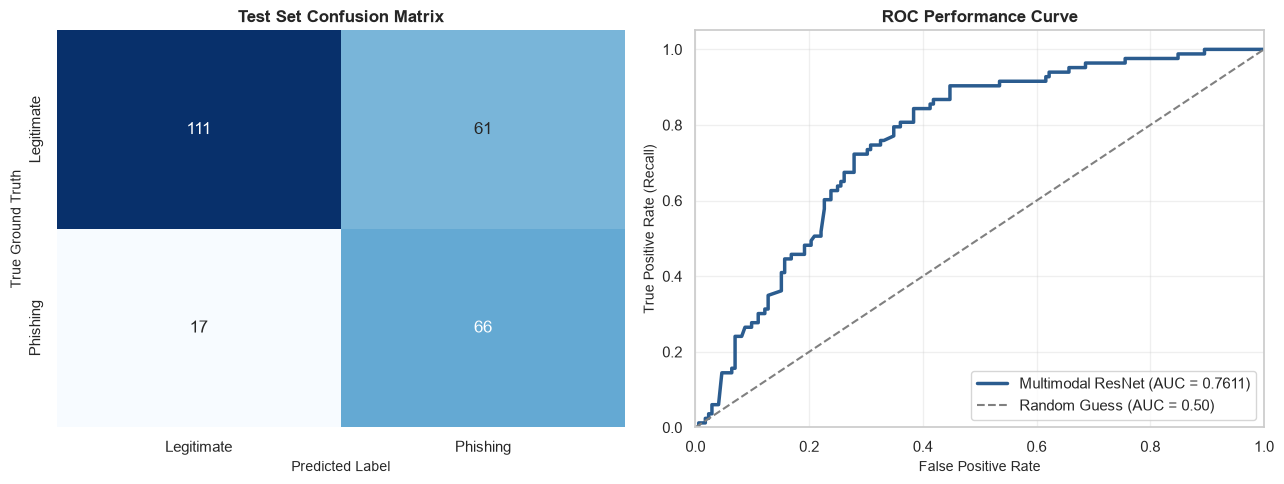


✅ Phase 9 Complete!


In [ ]:
# ==============================================================================
# PHASE 9: MULTIMODAL TEST EVALUATION, CONFUSION MATRIX & ROC-AUC
# ==============================================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("=== PHASE 9: MULTIMODAL TEST SET EVALUATION ===")

# 1. Load the best multimodal model checkpoint
checkpoint_path = "best_multimodal_phishnet.pth"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"📦 Loaded best model weights from: '{checkpoint_path}'")
else:
    print("⚠️ Checkpoint file not found on disk, using current model weights in memory.")

model.eval()

test_preds = []
test_probs = []
test_true = []

# 2. Run inference across the multimodal test DataLoader
with torch.no_grad():
    for images, text_feats, labels in test_loader:
        images = images.to(device)
        text_feats = text_feats.to(device)
        
        outputs = model(images, text_feats)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs >= 0.50).astype(int)
        
        test_probs.extend(probs)
        test_preds.extend(preds)
        test_true.extend(labels.numpy().flatten().astype(int))

test_true = np.array(test_true)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

# 3. Compute Confusion Matrix
cm = confusion_matrix(test_true, test_preds)
tn, fp, fn, tp = cm.ravel()
n_test_genuine = (test_true == 0).sum()
n_test_phishing = (test_true == 1).sum()

# 4. Display Text Results
print("\n📋 --- FINAL TEST CONFUSION MATRIX ---")
print(f"   [ Genuine Correctly Cleared   (TN) ]: {tn:3d} / {n_test_genuine}")
print(f"   [ Genuine Flagged as Threat   (FP) ]: {fp:3d} (False Alarms)")
print(f"   [ Phishing Missed by AI       (FN) ]: {fn:3d} (Missed Threats)")
print(f"   [ Phishing Successfully Caught(TP) ]: {tp:3d} / {n_test_phishing}")

print("\n🎯 --- CLASSIFICATION METRICS REPORT ---")
print(classification_report(test_true, test_preds, target_names=["0: Genuine", "1: Phishing"], digits=4))

# 5. ROC-AUC Score
auc_score = roc_auc_score(test_true, test_probs)
print(f"🌟 Area Under ROC Curve (AUC-ROC): {auc_score:.4f} (1.0000 is perfect)")

# 6. Generate Diagnostic Plots (Confusion Matrix & ROC Curve)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix Heatmap
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"],
    ax=ax1
)
ax1.set_title("Test Set Confusion Matrix", fontsize=12, fontweight='bold')
ax1.set_xlabel("Predicted Label", fontsize=10)
ax1.set_ylabel("True Ground Truth", fontsize=10)

# ROC Curve Plot
fpr, tpr, _ = roc_curve(test_true, test_probs)
ax2.plot(fpr, tpr, color="#2b5c8f", lw=2.5, label=f"Multimodal ResNet (AUC = {auc_score:.4f})")
ax2.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1.5, label="Random Guess (AUC = 0.50)")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("False Positive Rate", fontsize=10)
ax2.set_ylabel("True Positive Rate (Recall)", fontsize=10)
ax2.set_title("ROC Performance Curve", fontsize=12, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Phase 9 Complete!")

=== INITIALIZING CYBERSHIELD DUAL-ENGINE VERIFICATION ===


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


✅ Model 2 (Multimodal Vision + OCR) Loaded Successfully.
✅ Model 1 (URL XGBoost Classifier) Loaded Successfully.
